In [1]:
!pip install torch_geometric

# ! pip install infomap networkx

!pip install pyg-lib -f https://data.pyg.org/whl/torch-2.6.0+cu124.html


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.0 MB/s eta 0:00:00a 0:00:01
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 46.6 MB/s eta 0:00:00a 0:00:01


In [2]:
import torch
print("Torch Version:", torch.__version__)
import numpy as np
import pandas as pd
from sklearn.decomposition import non_negative_factorization
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T
from collections import defaultdict
import numpy as np
import torch
import tqdm
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, to_hetero
from torch_geometric.loader import LinkNeighborLoader
from torch import Tensor
from networkx.algorithms.community.quality import modularity
from typing import Dict, List, Tuple
import torch.nn as nn
import numpy as np
from math import log2

Torch Version: 2.6.0+cu124


In [3]:
ratings_df = pd.read_csv("/kaggle/input/personality-2018/personality-isf2018/ratings.csv")
personality_df = pd.read_csv("/kaggle/input/personality-2018/personality-isf2018/personality-data.csv")
movies_df = pd.read_csv('/kaggle/input/movielens-25m/ml-25m/movies.csv')

ratings_df.columns=ratings_df.columns.str.strip()
personality_df.columns=personality_df.columns.str.strip()

ratings_df.rename(columns={'useri':'userId','movie_id':'movieId'},inplace=True)
personality_df.rename(columns={'userid':'userId'},inplace=True)

In [4]:
# Create a mapping from unique user indices to range [0, num_user_nodes):
unique_user_id = ratings_df['userId'].unique()
unique_user_id = pd.DataFrame(data={
    'userId': unique_user_id,
    'mappedUserID': pd.RangeIndex(len(unique_user_id)),
})
print("Mapping of user IDs to consecutive values:")
print("==========================================")
print(unique_user_id.head())
print()
# Create a mapping from unique movie indices to range [0, num_movie_nodes):
unique_movie_id = ratings_df['movieId'].unique()
unique_movie_id = pd.DataFrame(data={
    'movieId': unique_movie_id,
    'mappedMovieID': pd.RangeIndex(len(unique_movie_id)),
})
print("Mapping of movie IDs to consecutive values:")
print("===========================================")
print(unique_movie_id.head())
# Perform merge to obtain the edges from users and movies:
ratings_user_id = pd.merge(ratings_df['userId'], unique_user_id,
                            left_on='userId', right_on='userId', how='left')
ratings_user_id = torch.from_numpy(ratings_user_id['mappedUserID'].values)
ratings_movie_id = pd.merge(ratings_df['movieId'], unique_movie_id,
                            left_on='movieId', right_on='movieId', how='left')
ratings_movie_id = torch.from_numpy(ratings_movie_id['mappedMovieID'].values)
# With this, we are ready to construct our `edge_index` in COO format
# following PyG semantics:
edge_index_user_to_movie = torch.stack([ratings_user_id, ratings_movie_id], dim=0)

print()
print("Final edge indices pointing from users to movies:")
print("=================================================")
print(edge_index_user_to_movie)


Mapping of user IDs to consecutive values:
                             userId  mappedUserID
0  8e7cebf9a234c064b75016249f2ac65e             0
1  77c7d756a093150d4377720abeaeef76             1
2  b7e8a92987a530cc368719a0e60e26a3             2
3  92561f21446e017dd6b68b94b23ad5b7             3
4  030001ac2145a938b07e686a35a2d638             4

Mapping of movie IDs to consecutive values:
   movieId  mappedMovieID
0        1              0
1        2              1
2        3              2
3        5              3
4        6              4

Final edge indices pointing from users to movies:
tensor([[    0,     0,     0,  ...,  1819,  1819,  1819],
        [    0,     1,     2,  ...,  5849, 32966,  6829]])


In [5]:
ratings_df = ratings_df.merge(unique_user_id, on='userId', how='left')
ratings_df = ratings_df.merge(unique_movie_id, on='movieId', how='left')
ratings_df = ratings_df.merge(movies_df[['genres', 'movieId']], on='movieId', how='left')
personality_df = personality_df.merge(unique_user_id, on='userId', how='left')

personality_columns=['openness', 'agreeableness', 'emotional_stability',
       'conscientiousness', 'extraversion']

personality_features=personality_df[['mappedUserID']+personality_columns]

filtered_personality = personality_features[personality_features.index.isin(ratings_df['mappedUserID'])]

filtered_personality = (
    personality_features[personality_features.index.isin(ratings_df['mappedUserID'])]
    .sort_values(by='mappedUserID', ascending=True)
)

# personality_features.drop('mappedUserID',axis=1,inplace=True)

filtered_personality

,mappedUserID,openness,agreeableness,emotional_stability,conscientiousness,extraversion
0,0,5.0,2.0,3.0,2.5,6.5
1,1,7.0,4.0,6.0,5.5,4.0
2,2,4.0,3.0,4.5,2.0,2.5
3,3,5.5,5.5,4.0,4.5,4.0
4,4,5.5,5.5,3.5,4.5,2.5
...,...,...,...,...,...,...
1815,1801,5.5,4.5,3.5,4.5,4.5
1816,1802,4.0,3.0,5.0,5.0,4.0
1817,1803,5.0,5.5,4.0,3.0,4.5
1818,1804,4.0,6.0,3.0,5.0,1.5


In [6]:
shuffled_personality = filtered_personality.copy()

# Shuffle all trait columns as a block
shuffled_traits = (
    shuffled_personality[personality_columns]
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

# Keep mappedUserID order, but assign new random traits
shuffled_personality[personality_columns] = shuffled_traits
shuffled_personality

,mappedUserID,openness,agreeableness,emotional_stability,conscientiousness,extraversion
0,0,7.0,6.0,6.0,5.0,4.0
1,1,4.5,2.5,4.5,2.5,2.0
2,2,5.0,5.5,7.0,7.0,1.5
3,3,7.0,7.0,4.5,4.0,3.0
4,4,5.5,3.5,4.0,4.5,3.0
...,...,...,...,...,...,...
1815,1801,7.0,4.0,3.5,4.0,2.5
1816,1802,6.0,5.0,7.0,4.5,3.5
1817,1803,3.0,2.0,4.5,5.5,1.5
1818,1804,7.0,4.0,3.0,2.0,4.0


In [7]:
num_users = 1820

user_ids = np.arange(num_users)

data = {
    "mappedUserID": user_ids,
    "openness": np.round(np.random.uniform(1, 10, num_users), 1),
    "agreeableness": np.round(np.random.uniform(1, 10, num_users), 1),
    "emotional_stability": np.round(np.random.uniform(1, 10, num_users), 1),
    "conscientiousness": np.round(np.random.uniform(1, 10, num_users), 1),
    "extraversion": np.round(np.random.uniform(1, 10, num_users), 1),
}

df1 = pd.DataFrame(data)
df1.head()

,mappedUserID,openness,agreeableness,emotional_stability,conscientiousness,extraversion
0,0,7.6,6.5,1.8,2.7,7.4
1,1,6.4,8.7,9.4,3.4,5.6
2,2,6.0,1.1,1.3,7.7,9.8
3,3,4.8,5.6,7.1,7.8,4.0
4,4,5.6,7.6,3.3,8.1,8.3


In [8]:
import numpy as np
from collections import defaultdict

seed = 42
rng = np.random.RandomState(seed)

interactions = edge_index_user_to_movie.numpy().T  # shape (num_edges, 2)
# each row = [user_id, movie_id]

min_interactions = 2  # we need at least 2 so that at least 1 stays in train

# Build per-user lists
user_to_items = defaultdict(list)
for u, i in interactions:
    user_to_items[int(u)].append(int(i))

train_edges = []
val_edges = []
test_edges = []

for u, items in user_to_items.items():
    n = len(items)
    if n < min_interactions:
        # not enough to hold out, keep all in train
        train_edges.extend([(u, i) for i in items])
        continue

    # pick 1 test edge
    test_i = rng.choice(items, size=1)[0]
    test_edges.append((u, test_i))

    remaining = [i for i in items if i != test_i]

    if len(remaining) >= 2:
        # pick 1 validation edge
        val_i = rng.choice(remaining, size=1)[0]
        val_edges.append((u, val_i))
        remaining = [i for i in remaining if i != val_i]

    # all others go to train
    train_edges.extend([(u, i) for i in remaining])

train_edges = np.array(train_edges, dtype=int)
val_edges = np.array(val_edges, dtype=int)
test_edges = np.array(test_edges, dtype=int)

print("train edges:", len(train_edges),
      "val edges:", len(val_edges),
      "test edges:", len(test_edges))


train edges: 1025084 val edges: 1819 test edges: 1820


In [9]:
from torch_geometric.data import HeteroData
import torch
from torch_geometric.transforms import ToUndirected

data = HeteroData()

# Save node indices:
data["user"].node_id = torch.arange(len(unique_user_id))
data["movie"].node_id = torch.arange(len(unique_movie_id))

# set user features (personality or shuffled/random)
data['user'].x = torch.tensor(filtered_personality.drop('mappedUserID',axis=1).values, dtype=torch.float32)
# movie features if any; otherwise skip or use None

# Build edge_index from train_edges
# train_edges is np.array([[u,i],...])
edge_index = torch.tensor(train_edges.T, dtype=torch.long).contiguous()  # shape (2, E)
data["user","rates","movie"].edge_index = edge_index

# add reverse edge type for hetero GNN
data = ToUndirected()(data)


In [10]:
from torch_geometric.loader import LinkNeighborLoader

# Use train_edges for supervision
edge_label_index = torch.tensor(train_edges.T, dtype=torch.long)
edge_label = torch.ones(edge_label_index.size(1), dtype=torch.float)

train_loader = LinkNeighborLoader(
    data=data,
    num_neighbors=[20, 10],
    neg_sampling_ratio=2.0,   # negatives generated on-the-fly
    edge_label_index=(("user", "rates", "movie"), edge_label_index),
    edge_label=edge_label,
    batch_size=128,
    shuffle=True,
)


In [11]:
class GNN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.conv1 = SAGEConv(hidden_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
    def forward(self, x: Tensor, edge_index: Tensor) -> Tensor:
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

class Classifier(torch.nn.Module):
    def forward(self, x_user: Tensor, x_movie: Tensor, edge_label_index: Tensor) -> Tensor:
        edge_feat_user = x_user[edge_label_index[0]]
        edge_feat_movie = x_movie[edge_label_index[1]]
        return (edge_feat_user * edge_feat_movie).sum(dim=-1)

class PersonalityPredictor(torch.nn.Module):
    def __init__(self, in_channels, out_channels=5):
        super().__init__()
        self.lin1 = torch.nn.Linear(in_channels, in_channels)
        self.lin2 = torch.nn.Linear(in_channels, out_channels)

    def forward(self, x_user: Tensor) -> Tensor:
        x = F.relu(self.lin1(x_user))
        x = self.lin2(x) 
        return x

class Model_linear(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        # Since the dataset does not come with rich features, we also learn two
        # embedding matrices for users and movies:
        #self.movie_lin = torch.nn.Linear(27, hidden_channels)
        self.user_lin = torch.nn.Linear(5, hidden_channels)
        self.user_emb = torch.nn.Embedding(data["user"].num_nodes, hidden_channels)
        self.movie_emb = torch.nn.Embedding(data["movie"].num_nodes, hidden_channels)
        # Instantiate homogeneous GNN:
        self.gnn = GNN(hidden_channels)
        # Convert GNN model into a heterogeneous variant:
        self.gnn = to_hetero(self.gnn, metadata=data.metadata())
        self.classifier = Classifier()
    def forward(self, data: HeteroData) -> Tensor:
        x_dict = {
          "user": self.user_emb(data["user"].node_id)+self.user_lin(data["user"].x),
          # "user": self.user_emb(data["user"].node_id),
          "movie":  self.movie_emb(data["movie"].node_id),
        } 
        # `x_dict` holds feature matrices of all node types
        # `edge_index_dict` holds all edge indices of all edge types
        x_dict = self.gnn(x_dict, data.edge_index_dict)
        pred = self.classifier(
            x_dict["user"],
            x_dict["movie"],
            data["user", "rates", "movie"].edge_label_index,
        )
        return pred
        

In [12]:
class Model_concat(torch.nn.Module):
    def __init__(self, hidden_channels, user_feature_dim=5):
        super().__init__()
        # Embedding for capturing structural information
        self.user_emb = torch.nn.Embedding(data["user"].num_nodes, hidden_channels)
        self.movie_emb = torch.nn.Embedding(data["movie"].num_nodes, hidden_channels)

        # A linear layer to process the raw personality features
        # Note: its output size can be different from hidden_channels if you want
        self.user_feat_lin = torch.nn.Linear(user_feature_dim, hidden_channels)

        # A new linear layer to combine the embedding and the processed features
        # Input size is 2 * hidden_channels because we concatenate two vectors of that size
        self.user_combiner = torch.nn.Linear(hidden_channels * 2, hidden_channels)

        # Instantiate homogeneous GNN:
        self.gnn = GNN(hidden_channels)
        # Convert GNN model into a heterogeneous variant:
        self.gnn = to_hetero(self.gnn, metadata=data.metadata())
        self.classifier = Classifier()

    def forward(self, data: HeteroData) -> Tensor:
        # 1. Get structural embedding
        user_embedding = self.user_emb(data["user"].node_id)
        
        # 2. Process personality features
        user_features = self.user_feat_lin(data["user"].x)
        user_features = F.relu(user_features) # Add a non-linearity

        # 3. Concatenate and combine
        combined_user_vec = torch.cat([user_embedding, user_features], dim=1)
        initial_user_x = self.user_combiner(combined_user_vec)

        x_dict = {
          "user": initial_user_x,
          "movie": self.movie_emb(data["movie"].node_id),
        }
        
        # Proceed as before
        x_dict = self.gnn(x_dict, data.edge_index_dict)
        pred = self.classifier(
            x_dict["user"],
            x_dict["movie"],
            data["user", "rates", "movie"].edge_label_index,
        )
        return pred


In [13]:
class Model_mtl(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
    
        self.user_lin = torch.nn.Linear(5, hidden_channels)
        self.user_emb = torch.nn.Embedding(data["user"].num_nodes, hidden_channels)
        self.movie_emb = torch.nn.Embedding(data["movie"].num_nodes, hidden_channels)

        self.gnn = GNN(hidden_channels)
        self.gnn = to_hetero(self.gnn, metadata=data.metadata())

        self.classifier = Classifier()
        self.personality_predictor = PersonalityPredictor(hidden_channels, out_channels=5)

    def forward(self, data: HeteroData) -> dict:
        x_dict = {
          "user": self.user_emb(data["user"].node_id) + self.user_lin(data["user"].x),
          "movie": self.movie_emb(data["movie"].node_id),
        }

        final_x_dict = self.gnn(x_dict, data.edge_index_dict)

        pred_link = self.classifier(
            final_x_dict["user"],
            final_x_dict["movie"],
            data["user", "rates", "movie"].edge_label_index,
        )

        pred_personality = self.personality_predictor(final_x_dict["user"])

        return {"link": pred_link, "personality": pred_personality}


In [14]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Device: '{device}'")
# model = Model_linear(hidden_channels=5).to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# for epoch in range(1, 7):
#     total_loss = total_examples = 0
#     for sampled_data in tqdm.tqdm(train_loader):
#         optimizer.zero_grad()
#         sampled_data.to(device)
#         pred = model(sampled_data)
#         ground_truth = sampled_data["user", "rates", "movie"].edge_label
#         loss = F.binary_cross_entropy_with_logits(pred, ground_truth)
#         loss.backward()
#         optimizer.step()
#         total_loss += float(loss) * pred.numel()
#         total_examples += pred.numel()
#     print(f"Epoch: {epoch:03d}, Loss: {total_loss / total_examples:.4f}")

In [15]:
import copy
from math import log2
from collections import defaultdict

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

def evaluate_embeddings(user_emb_np, movie_emb_np, test_edges, train_edges_set,
                        num_negatives=99, K_list=(3,5,10), rng=None):
    if rng is None:
        rng = np.random.RandomState(0)

    hits = {k: 0 for k in K_list}
    ndcg = {k: 0.0 for k in K_list}
    count = 0
    num_items = movie_emb_np.shape[0]

    for (u,pos) in test_edges:
        u = int(u); pos = int(pos)
        negs = []
        while len(negs) < num_negatives:
            cand = int(rng.randint(0, num_items))
            if cand == pos or cand in train_edges_set[u]:
                continue
            negs.append(cand)
        candidates = [pos] + negs
        scores = movie_emb_np[candidates] @ user_emb_np[u]
        order = np.argsort(-scores)
        rank_of_pos = int(np.where(order == 0)[0][0])
        count += 1
        for K in K_list:
            if rank_of_pos < K:
                hits[K] += 1
                ndcg[K] += 1.0 / log2(rank_of_pos + 2)
    return {f"HR@{K}": hits[K]/count for K in K_list}, {f"NDCG@{K}": ndcg[K]/count for K in K_list}

def train_and_evaluate_with_val(
    model_class,
    hidden_channels=5,
    num_epochs=15,
    seed=42,
    personality_loss_weight=0.5,
    lr=1e-3,
    patience=2,
    verbose=True
):
    torch.manual_seed(seed); np.random.seed(seed)

    # Move full graph to device
    data_device = data.to(device)

    # ---- Use prebuilt splits directly ----
    train_edges_split = train_edges
    val_edges_split = val_edges

    # Build a LinkNeighborLoader for training using train_edges
    edge_label_index = torch.tensor(train_edges_split.T, dtype=torch.long)
    edge_label = torch.ones(edge_label_index.size(1), dtype=torch.float)

    train_loader_local = LinkNeighborLoader(
        data=data_device,
        num_neighbors=[20,10],
        neg_sampling_ratio=2.0,
        edge_label_index=(("user","rates","movie"), edge_label_index),
        edge_label=edge_label,
        batch_size=128,
        shuffle=True,
    )

    # Precompute train set mapping for metrics
    user_train_set = defaultdict(set)
    for u,i in train_edges_split:
        user_train_set[int(u)].add(int(i))

    # Initialize model
    model = model_class(hidden_channels).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_score = -np.inf
    best_state = None
    epochs_no_improve = 0

    # training loop
    for epoch in range(1, num_epochs+1):
        model.train()
        total_loss = total_examples = 0.0
        total_link_loss = 0.0
        total_personality_loss = 0.0

        for sampled_data in train_loader_local:
            sampled_data = sampled_data.to(device)
            optimizer.zero_grad()
            pred_out = model(sampled_data)

            if isinstance(pred_out, dict):
                pred_link = pred_out["link"]
                pred_personality = pred_out["personality"]
                ground_truth_link = sampled_data["user","rates","movie"].edge_label
                user_original_ids = sampled_data["user"].n_id
                ground_truth_personality = data_device["user"].x[user_original_ids]

                loss_link = F.binary_cross_entropy_with_logits(pred_link, ground_truth_link)
                loss_personality = F.mse_loss(pred_personality, ground_truth_personality)
                loss = loss_link + personality_loss_weight * loss_personality
                total_link_loss += float(loss_link) * pred_link.numel()
                total_personality_loss += float(loss_personality) * pred_personality.shape[0]
            else:
                pred_link = pred_out
                ground_truth_link = sampled_data["user","rates","movie"].edge_label
                loss = F.binary_cross_entropy_with_logits(pred_link, ground_truth_link)

            loss.backward()
            optimizer.step()

            total_loss += float(loss) * pred_link.numel()
            total_examples += pred_link.numel()

        avg_loss = total_loss / (total_examples + 1e-12)
        if verbose:
            if isinstance(pred_out, dict):
                print(f"Epoch {epoch:03d} | Loss {avg_loss:.4f} | Link {total_link_loss/total_examples:.4f} | Pers {total_personality_loss/total_examples:.4f}")
            else:
                print(f"Epoch {epoch:03d} | Loss {avg_loss:.4f}")

        # ---- validation evaluation ----
        model.eval()
        with torch.no_grad():
            if model_class == Model_concat:
                user_embedding = model.user_emb(data_device["user"].node_id)
                user_features = F.relu(model.user_feat_lin(data_device["user"].x))
                combined_user_vec = torch.cat([user_embedding, user_features], dim=1)
                initial_user_x = model.user_combiner(combined_user_vec)
                x_dict = {"user": initial_user_x, "movie": model.movie_emb(data_device["movie"].node_id)}
            else:
                x_dict = {"user": model.user_emb(data_device["user"].node_id) + model.user_lin(data_device["user"].x),
                          "movie": model.movie_emb(data_device["movie"].node_id)}

            final_x = model.gnn(x_dict, data_device.edge_index_dict)
            user_emb_np = final_x["user"].cpu().numpy()
            movie_emb_np = final_x["movie"].cpu().numpy()

            hr_dict, ndcg_dict = evaluate_embeddings(
                user_emb_np, movie_emb_np,
                val_edges_split, user_train_set,
                num_negatives=99, K_list=(3,5,10),
                rng=np.random.RandomState(seed+epoch)
            )

            val_score = ndcg_dict["NDCG@10"]

            if verbose:
                print(f"  Val NDCG@3 {ndcg_dict['NDCG@3']:.4f}  NDCG@5 {ndcg_dict['NDCG@5']:.4f}  NDCG@10 {ndcg_dict['NDCG@10']:.4f}")

        # ---- early stopping ----
        if val_score > best_val_score + 1e-6:
            best_val_score = val_score
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            if verbose: print(f"  New best val NDCG@10: {best_val_score:.6f} (saved)")
        else:
            epochs_no_improve += 1
            if verbose: print(f"  No improvement for {epochs_no_improve} epochs")
            if epochs_no_improve >= patience:
                if verbose: print("Early stopping triggered.")
                break

    # restore best model
    if best_state is not None:
        model.load_state_dict(best_state)

    # ---- final test evaluation ----
    model.eval()
    with torch.no_grad():
        if model_class == Model_concat:
            user_embedding = model.user_emb(data_device["user"].node_id)
            user_features = F.relu(model.user_feat_lin(data_device["user"].x))
            combined_user_vec = torch.cat([user_embedding, user_features], dim=1)
            initial_user_x = model.user_combiner(combined_user_vec)
            x_dict = {"user": initial_user_x, "movie": model.movie_emb(data_device["movie"].node_id)}
        else:
            x_dict = {"user": model.user_emb(data_device["user"].node_id) + model.user_lin(data_device["user"].x),
                      "movie": model.movie_emb(data_device["movie"].node_id)}

        final_x = model.gnn(x_dict, data_device.edge_index_dict)
        user_emb_np = final_x["user"].cpu().numpy()
        movie_emb_np = final_x["movie"].cpu().numpy()

        # recompute full train set mapping (train+val go into "known positives")
        full_train_set = defaultdict(set)
        for u,i in np.vstack([train_edges, val_edges]):
            full_train_set[int(u)].add(int(i))

        hr_test, ndcg_test = evaluate_embeddings(
            user_emb_np, movie_emb_np,
            test_edges, full_train_set,
            num_negatives=99, K_list=(3,5,10),
            rng=np.random.RandomState(seed+999)
        )

    results = {}
    results.update(hr_test)
    results.update(ndcg_test)
    return results, model

def run_multiple(model_class, num_runs=3, **kwargs):
    all_metrics = []
    for run in range(num_runs):
        print(f"\n===== Run {run+1}/{num_runs} for {model_class.__name__} =====")
        # change seed each run to vary split/negatives
        seed = kwargs.get("seed", 42) + run * 100  
        metrics, _ = train_and_evaluate_with_val(model_class, seed=seed, **kwargs)
        all_metrics.append(metrics)

    # average across runs
    avg_metrics = {}
    for key in all_metrics[0].keys():
        avg_metrics[key] = np.mean([m[key] for m in all_metrics])
    return avg_metrics, all_metrics

# # Example usage
# avg_metrics, all_metrics = run_multiple(Model_linear, num_runs=3,
#                                         hidden_channels=5,
#                                         num_epochs=15,
#                                         lr=1e-3,
#                                         patience=2)

# print("\nPer-run metrics:")
# for i, m in enumerate(all_metrics, 1):
#     print(f"Run {i}: {m}")

# print("\nAverage metrics across runs:")
# for k,v in avg_metrics.items():
#     print(f"{k}: {v:.4f}")



Device: cuda


In [16]:
avg_metrics, all_metrics = run_multiple(Model_mtl, num_runs=3,
                                        hidden_channels=5,
                                        num_epochs=15,
                                        lr=1e-3,
                                        patience=3)

print("\nPer-run metrics:")
for i, m in enumerate(all_metrics, 1):
    print(f"Run {i}: {m}")

print("\nAverage metrics across runs:")
for k,v in avg_metrics.items():
    print(f"{k}: {v:.4f}")


===== Run 1/3 for Model_mtl =====
Epoch 001 | Loss 1.0577 | Link 0.2986 | Pers 5.0974
  Val NDCG@3 0.3373  NDCG@5 0.3951  NDCG@10 0.4525
  New best val NDCG@10: 0.452464 (saved)
Epoch 002 | Loss 0.8121 | Link 0.2520 | Pers 3.7645
  Val NDCG@3 0.2542  NDCG@5 0.3255  NDCG@10 0.3974
  No improvement for 1 epochs
Epoch 003 | Loss 0.6046 | Link 0.2465 | Pers 2.4065
  Val NDCG@3 0.3512  NDCG@5 0.4040  NDCG@10 0.4641
  New best val NDCG@10: 0.464100 (saved)


KeyboardInterrupt: 

In [20]:
avg_metrics, all_metrics = run_multiple(Model_mtl, num_runs=3,
                                        hidden_channels=5,
                                        num_epochs=15,
                                        lr=1e-3,
                                        patience=2)

print("\nPer-run metrics:")
for i, m in enumerate(all_metrics, 1):
    print(f"Run {i}: {m}")

print("\nAverage metrics across runs:")
for k,v in avg_metrics.items():
    print(f"{k}: {v:.4f}")


===== Run 1/3 for Model_mtl =====
Epoch 001 | Loss 2.1316 | Link 0.3304 | Pers 12.1019
  Val NDCG@3 0.1354  NDCG@5 0.2051  NDCG@10 0.2879
  New best val NDCG@10: 0.287885 (saved)
Epoch 002 | Loss 1.2062 | Link 0.2945 | Pers 6.1226
  Val NDCG@3 0.3577  NDCG@5 0.4150  NDCG@10 0.4703
  New best val NDCG@10: 0.470257 (saved)
Epoch 003 | Loss 0.9243 | Link 0.2799 | Pers 4.3276
  Val NDCG@3 0.3879  NDCG@5 0.4453  NDCG@10 0.4911
  New best val NDCG@10: 0.491061 (saved)
Epoch 004 | Loss 0.6559 | Link 0.3153 | Pers 2.2870
  Val NDCG@3 0.3960  NDCG@5 0.4493  NDCG@10 0.4986
  New best val NDCG@10: 0.498609 (saved)
Epoch 005 | Loss 0.6172 | Link 0.3093 | Pers 2.0679
  Val NDCG@3 0.3964  NDCG@5 0.4560  NDCG@10 0.5045
  New best val NDCG@10: 0.504487 (saved)
Epoch 006 | Loss 0.5959 | Link 0.3037 | Pers 1.9619
  Val NDCG@3 0.4055  NDCG@5 0.4609  NDCG@10 0.5101
  New best val NDCG@10: 0.510144 (saved)
Epoch 007 | Loss 0.5836 | Link 0.3005 | Pers 1.9012
  Val NDCG@3 0.4313  NDCG@5 0.4858  NDCG@10 0.53

In [17]:
import numpy as np
import pandas as pd

def sweep_lambda(
    model_class,
    lambdas=[0.0, 0.05, 0.1, 0.25, 0.4, 0.6, 0.8, 1.0],
    num_runs=3,
    hidden_channels=5,
    num_epochs=15,
    lr=1e-3,
    patience=2,
):
    results = []

    for lam in lambdas:
        print(f"\n===== Testing λ = {lam} =====")
        avg_metrics, _ = run_multiple(
            model_class,
            num_runs=num_runs,
            hidden_channels=hidden_channels,
            num_epochs=num_epochs,
            lr=lr,
            patience=patience,
            personality_loss_weight=lam,
        )
        
        row = {"lambda": lam}
        row.update(avg_metrics)
        results.append(row)

    return pd.DataFrame(results)


# Example usage:
lambda_scan_df = sweep_lambda(
    Model_mtl,
    lambdas=[0.0, 0.05, 0.1, 0.25, 0.4, 0.6, 0.8, 1.0],
    num_runs=2,            # speedup for testing; use 3 or 5 for paper
    hidden_channels=5,
    num_epochs=12,         # also speed; tune higher later
    lr=1e-3,
    patience=2,
)

lambda_scan_df
lambda_scan_df.plot(x='lambda', y=['NDCG@10','HR@10'], marker='o')



===== Testing λ = 0.0 =====

===== Run 1/2 for Model_mtl =====
Epoch 001 | Loss 0.2750 | Link 0.2750 | Pers 74.1983
  Val NDCG@3 0.4863  NDCG@5 0.5319  NDCG@10 0.5743
  New best val NDCG@10: 0.574327 (saved)
Epoch 002 | Loss 0.2400 | Link 0.2400 | Pers 74.2231
  Val NDCG@3 0.4510  NDCG@5 0.4969  NDCG@10 0.5436
  No improvement for 1 epochs
Epoch 003 | Loss 0.2336 | Link 0.2336 | Pers 74.1571
  Val NDCG@3 0.4593  NDCG@5 0.5015  NDCG@10 0.5489
  No improvement for 2 epochs
Early stopping triggered.

===== Run 2/2 for Model_mtl =====
Epoch 001 | Loss 0.2775 | Link 0.2775 | Pers 70.7940
  Val NDCG@3 0.3602  NDCG@5 0.4133  NDCG@10 0.4707
  New best val NDCG@10: 0.470740 (saved)
Epoch 002 | Loss 0.2430 | Link 0.2430 | Pers 71.3565
  Val NDCG@3 0.3365  NDCG@5 0.3905  NDCG@10 0.4474
  No improvement for 1 epochs
Epoch 003 | Loss 0.2351 | Link 0.2351 | Pers 71.9388
  Val NDCG@3 0.3559  NDCG@5 0.4101  NDCG@10 0.4669
  No improvement for 2 epochs
Early stopping triggered.

===== Testing λ = 0.05

KeyboardInterrupt: 

In [18]:
###############################################################
# Noise Distributions
###############################################################

def make_noise(num_users: int, num_feats: int, dist: str, seed=42):
    rng = np.random.RandomState(seed)

    if dist == "uniform":
        # Match personality scale 1..10
        return rng.uniform(1, 10, size=(num_users, num_feats))

    elif dist == "normal":
        # mean ~5, std ~2 (roughly like Big 5 raw scales)
        return rng.normal(loc=5.0, scale=2.0, size=(num_users, num_feats))

    elif dist == "laplace":
        # heavier tails
        return rng.laplace(loc=5.0, scale=1.5, size=(num_users, num_feats))

    elif dist == "bernoulli":
        # Lowest-information variant... binary “traits”
        # Probability skewed toward higher values
        return rng.binomial(n=1, p=0.6, size=(num_users, num_feats)).astype(float)

    elif dist == "exponential":
        # strictly positive; most mass near 1
        return rng.exponential(scale=4.0, size=(num_users, num_feats))

    else:
        raise ValueError(f"Unknown distribution: {dist}")


###############################################################
# Runner: Evaluate multiple noise distributions
###############################################################

def sweep_noise_distributions(
    distributions,
    model_class,
    num_runs=2,
    hidden_channels=5,
    num_epochs=12,
    lr=1e-3,
    patience=2,
    personality_loss_weight=0.25,  # fixed λ for all
):
    results = []

    num_users = data["user"].num_nodes
    num_feats = data["user"].x.shape[1]  # personality feature dim

    for dist in distributions:
        print(f"\n===== Testing Noise Distribution: {dist} =====")

        # Generate synthetic noise traits
        noise_mat = make_noise(num_users, num_feats, dist, seed=42)
        data["user"].x = torch.tensor(noise_mat, dtype=torch.float32)

        # Plug and play: model trains with the new features
        avg_metrics, _ = run_multiple(
            model_class,
            num_runs=num_runs,
            hidden_channels=hidden_channels,
            num_epochs=num_epochs,
            lr=lr,
            patience=patience,
            personality_loss_weight=personality_loss_weight,
        )

        row = {"distribution": dist}
        row.update(avg_metrics)
        results.append(row)

    return pd.DataFrame(results)


In [ ]:
distributions = [
    "uniform",
    "normal",
    "laplace",
    "bernoulli",
    "exponential"
]

noise_results_df = sweep_noise_distributions(
    distributions,
    Model_mtl,  # the MTL model with personality prediction head
    num_runs=2,  # increase to 3 or 5 for paper strength
    hidden_channels=5,
    num_epochs=12,
    lr=1e-3,
    patience=2,
    personality_loss_weight=0.25,
)

noise_results_df


In [55]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
data = data.to(device)  # train graph only

# Build initial x_dict exactly like your model.forward does
x_dict = {
    "user": model.user_emb(data["user"].node_id) + model.user_lin(data["user"].x),
    # "user": model.user_emb(data["user"].node_id),
    "movie": model.movie_emb(data["movie"].node_id)
}

# Compute final embeddings using the trained GNN (hetero)
model.eval()
with torch.no_grad():
    final_x = model.gnn(x_dict, data.edge_index_dict)
    user_emb = final_x["user"]   # tensor (num_users, d)
    movie_emb = final_x["movie"] # tensor (num_items, d)


ERROR! Session/line number was not unique in database. History logging moved to new session 29


In [36]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
data = data.to(device)  # train graph only

model.eval()
with torch.no_grad():
    # Step 1. Structural embedding
    user_embedding = model.user_emb(data["user"].node_id)
    
    # Step 2. Process personality features
    user_features = model.user_feat_lin(data["user"].x)
    user_features = F.relu(user_features)
    
    # Step 3. Concatenate and combine
    combined_user_vec = torch.cat([user_embedding, user_features], dim=1)
    initial_user_x = model.user_combiner(combined_user_vec)
    
    # Step 4. Build x_dict
    x_dict = {
        "user": initial_user_x,
        "movie": model.movie_emb(data["movie"].node_id),
    }
    
    # Step 5. Pass through GNN
    final_x = model.gnn(x_dict, data.edge_index_dict)
    
    # Final embeddings
    user_emb = final_x["user"]   # shape (num_users, hidden_channels)
    movie_emb = final_x["movie"] # shape (num_items, hidden_channels)


In [56]:
import numpy as np
from math import log2

num_negatives = 99
K_list = [3,5,10]
rng = np.random.RandomState(seed)

# Precompute user -> set of train items for quick check
user_train_set = defaultdict(set)
for u,i in train_edges:
    user_train_set[int(u)].add(int(i))

# Evaluate
hits = {k: 0 for k in K_list}
ndcg = {k: 0.0 for k in K_list}
count = 0

num_items = len(unique_movie_id)

with torch.no_grad():
    # convert embeddings to cpu numpy for faster scoring loop if memory allows
    user_emb_np = user_emb.cpu().numpy()
    movie_emb_np = movie_emb.cpu().numpy()

    for (u,pos) in test_edges:
        u = int(u); pos = int(pos)
        # sample negatives (ensure they are not in user's train set and not the pos)
        negs = []
        while len(negs) < num_negatives:
            cand = int(rng.randint(0, num_items))
            if cand == pos or cand in user_train_set[u]:
                continue
            negs.append(cand)
        candidates = [pos] + negs  # pos first (index 0)
        
        # compute scores: dot product
        u_vec = user_emb_np[u]          # (d,)
        cand_vecs = movie_emb_np[candidates]  # (100, d)
        scores = cand_vecs @ u_vec      # (100,)
        
        # rank descending
        order = np.argsort(-scores)
        rank_of_pos = int(np.where(order == 0)[0][0])  # 0-indexed position of pos in sorted list
        
        count += 1
        for K in K_list:
            if rank_of_pos < K:
                hits[K] += 1
                ndcg[K] += 1.0 / log2(rank_of_pos + 2)  # rank_of_pos is 0-based -> position = rank_of_pos+1
            # else HR contribution is 0 and NDCG contribution is 0

# Final metrics
for K in K_list:
    hr = hits[K] / count
    ndcg_val = ndcg[K] / count
    print(f"HR@{K}: {hr:.4f}, NDCG@{K}: {ndcg_val:.4f}")


HR@3: 0.5775, NDCG@3: 0.4727
HR@5: 0.6852, NDCG@5: 0.5172
HR@10: 0.8346, NDCG@10: 0.5657


In [51]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: '{device}'")

data = data.to(device)
model = Model_mtl(hidden_channels=5).to(device) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

personality_loss_weight = 0.5

for epoch in range(1, 7):
    total_loss = 0
    total_link_loss = 0
    total_personality_loss = 0
    total_examples = 0

    for sampled_data in tqdm.tqdm(train_loader):
        optimizer.zero_grad()
        sampled_data.to(device)

        pred_dict = model(sampled_data)
        pred_link = pred_dict["link"]
        pred_personality = pred_dict["personality"]

        ground_truth_link = sampled_data["user", "rates", "movie"].edge_label

        user_original_ids = sampled_data["user"].n_id
        ground_truth_personality = data["user"].x[user_original_ids]

        loss_link = F.binary_cross_entropy_with_logits(pred_link, ground_truth_link)
        loss_personality = F.mse_loss(pred_personality, ground_truth_personality)

        loss = loss_link + personality_loss_weight * loss_personality

        loss.backward()
        optimizer.step()

        total_loss += float(loss) * pred_link.numel()
        total_link_loss += float(loss_link) * pred_link.numel()
        total_personality_loss += float(loss_personality) * pred_personality.shape[0] 
        total_examples += pred_link.numel()

    avg_total_loss = total_loss / total_examples
    avg_link_loss = total_link_loss / total_examples
    avg_personality_loss = total_personality_loss / total_examples

    print(f"Epoch: {epoch:03d}, Total Loss: {avg_total_loss:.4f}, "
          f"Link Loss: {avg_link_loss:.4f}, Pers. Loss: {avg_personality_loss:.4f}")

Device: 'cuda'


100%|██████████| 8023/8023 [01:10<00:00, 113.14it/s]


Epoch: 001, Total Loss: 0.6209, Link Loss: 0.2499, Pers. Loss: 2.4975


100%|██████████| 8023/8023 [01:10<00:00, 113.30it/s]


Epoch: 002, Total Loss: 0.5483, Link Loss: 0.2316, Pers. Loss: 2.1328


...

Epoch: 004, Total Loss: 0.5213, Link Loss: 0.2263, Pers. Loss: 1.9864


100%|██████████| 8023/8023 [01:10<00:00, 113.11it/s]


Epoch: 005, Total Loss: 0.5185, Link Loss: 0.2252, Pers. Loss: 1.9744


 12%|█▏        | 948/8023 [00:08<01:03, 112.14it/s]


KeyboardInterrupt: 

Device: cuda

===== Run 1/1 for Model_linear =====
Epoch 001 | Loss 0.2736 | Val HR@5 0.6663 | Val NDCG@5 0.4995
  New best val NDCG@10: 0.542251 (saved)
Epoch 002 | Loss 0.2400 | Val HR@5 0.6553 | Val NDCG@5 0.4975
  New best val NDCG@10: 0.546069 (saved)
Epoch 003 | Loss 0.2333 | Val HR@5 0.6630 | Val NDCG@5 0.5008
  New best val NDCG@10: 0.547318 (saved)
Epoch 004 | Loss 0.2291 | Val HR@5 0.6410 | Val NDCG@5 0.4869
  No improvement for 1 epochs
Epoch 005 | Loss 0.2244 | Val HR@5 0.6487 | Val NDCG@5 0.4914
  No improvement for 2 epochs
Epoch 006 | Loss 0.2193 | Val HR@5 0.6493 | Val NDCG@5 0.4968
  No improvement for 3 epochs
Epoch 007 | Loss 0.2150 | Val HR@5 0.6460 | Val NDCG@5 0.4903
  No improvement for 4 epochs
Epoch 008 | Loss 0.2111 | Val HR@5 0.6625 | Val NDCG@5 0.5102
  New best val NDCG@10: 0.558577 (saved)
Epoch 009 | Loss 0.2082 | Val HR@5 0.6427 | Val NDCG@5 0.4806
  No improvement for 1 epochs
Epoch 010 | Loss 0.2062 | Val HR@5 0.6592 | Val NDCG@5 0.5029
  No improvemen

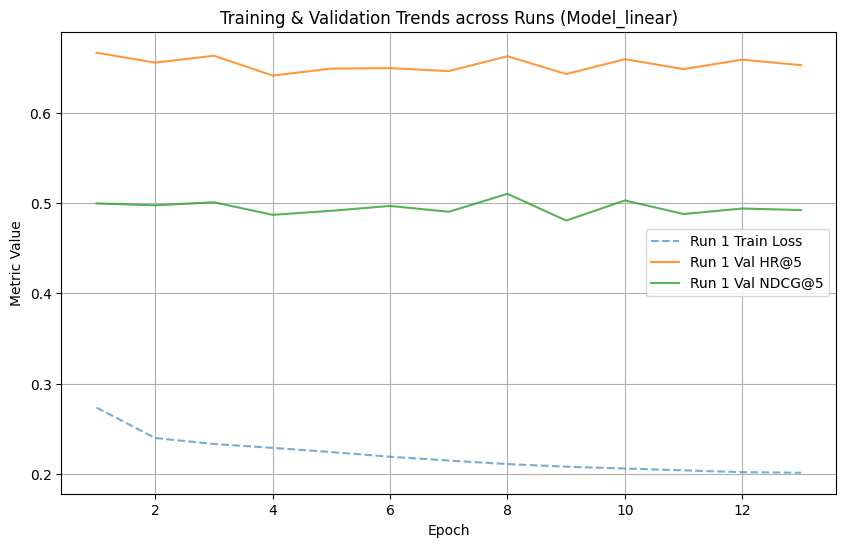

In [20]:
import copy
import numpy as np
import torch
import torch.nn.functional as F
from math import log2
from collections import defaultdict
import matplotlib.pyplot as plt  # NEW

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

def evaluate_embeddings(user_emb_np, movie_emb_np, test_edges, train_edges_set,
                        num_negatives=99, K_list=(3,5,10), rng=None):
    if rng is None:
        rng = np.random.RandomState(0)

    hits = {k: 0 for k in K_list}
    ndcg = {k: 0.0 for k in K_list}
    count = 0
    num_items = movie_emb_np.shape[0]

    for (u, pos) in test_edges:
        u = int(u); pos = int(pos)
        negs = []
        while len(negs) < num_negatives:
            cand = int(rng.randint(0, num_items))
            if cand == pos or cand in train_edges_set[u]:
                continue
            negs.append(cand)
        candidates = [pos] + negs
        scores = movie_emb_np[candidates] @ user_emb_np[u]
        order = np.argsort(-scores)
        rank_of_pos = int(np.where(order == 0)[0][0])
        count += 1
        for K in K_list:
            if rank_of_pos < K:
                hits[K] += 1
                ndcg[K] += 1.0 / log2(rank_of_pos + 2)
    return {f"HR@{K}": hits[K]/count for K in K_list}, {f"NDCG@{K}": ndcg[K]/count for K in K_list}


def train_and_evaluate_with_val(
    model_class,
    hidden_channels=5,
    num_epochs=15,
    seed=42,
    personality_loss_weight=0.5,
    lr=1e-3,
    patience=2,
    verbose=True
):
    torch.manual_seed(seed); np.random.seed(seed)

    data_device = data.to(device)

    train_edges_split = train_edges
    val_edges_split = val_edges

    edge_label_index = torch.tensor(train_edges_split.T, dtype=torch.long)
    edge_label = torch.ones(edge_label_index.size(1), dtype=torch.float)

    train_loader_local = LinkNeighborLoader(
        data=data_device,
        num_neighbors=[20, 10],
        neg_sampling_ratio=2.0,
        edge_label_index=(("user","rates","movie"), edge_label_index),
        edge_label=edge_label,
        batch_size=128,
        shuffle=True,
    )

    user_train_set = defaultdict(set)
    for u, i in train_edges_split:
        user_train_set[int(u)].add(int(i))

    model = model_class(hidden_channels).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_score = -np.inf
    best_state = None
    epochs_no_improve = 0

    # NEW: store history for plotting
    history = {"train_loss": [], "val_hr5": [], "val_ndcg5": []}

    for epoch in range(1, num_epochs+1):
        model.train()
        total_loss = total_examples = 0.0
        total_link_loss = 0.0
        total_personality_loss = 0.0

        for sampled_data in train_loader_local:
            sampled_data = sampled_data.to(device)
            optimizer.zero_grad()
            pred_out = model(sampled_data)

            if isinstance(pred_out, dict):
                pred_link = pred_out["link"]
                pred_personality = pred_out["personality"]
                ground_truth_link = sampled_data["user","rates","movie"].edge_label
                user_original_ids = sampled_data["user"].n_id
                ground_truth_personality = data_device["user"].x[user_original_ids]

                loss_link = F.binary_cross_entropy_with_logits(pred_link, ground_truth_link)
                loss_personality = F.mse_loss(pred_personality, ground_truth_personality)
                loss = loss_link + personality_loss_weight * loss_personality
                total_link_loss += float(loss_link) * pred_link.numel()
                total_personality_loss += float(loss_personality) * pred_personality.shape[0]
            else:
                pred_link = pred_out
                ground_truth_link = sampled_data["user","rates","movie"].edge_label
                loss = F.binary_cross_entropy_with_logits(pred_link, ground_truth_link)

            loss.backward()
            optimizer.step()

            total_loss += float(loss) * pred_link.numel()
            total_examples += pred_link.numel()

        avg_loss = total_loss / (total_examples + 1e-12)
        history["train_loss"].append(avg_loss)  # NEW

        # ---- validation evaluation ----
        model.eval()
        with torch.no_grad():
            if model_class == Model_concat:
                user_embedding = model.user_emb(data_device["user"].node_id)
                user_features = F.relu(model.user_feat_lin(data_device["user"].x))
                combined_user_vec = torch.cat([user_embedding, user_features], dim=1)
                initial_user_x = model.user_combiner(combined_user_vec)
                x_dict = {"user": initial_user_x, "movie": model.movie_emb(data_device["movie"].node_id)}
            else:
                x_dict = {
                    "user": model.user_emb(data_device["user"].node_id) + model.user_lin(data_device["user"].x),
                    "movie": model.movie_emb(data_device["movie"].node_id)
                }

            final_x = model.gnn(x_dict, data_device.edge_index_dict)
            user_emb_np = final_x["user"].cpu().numpy()
            movie_emb_np = final_x["movie"].cpu().numpy()

            hr_dict, ndcg_dict = evaluate_embeddings(
                user_emb_np, movie_emb_np,
                val_edges_split, user_train_set,
                num_negatives=99, K_list=(3,5,10),
                rng=np.random.RandomState(seed+epoch)
            )

            val_hr5 = hr_dict["HR@5"]
            val_ndcg5 = ndcg_dict["NDCG@5"]
            history["val_hr5"].append(val_hr5)     # NEW
            history["val_ndcg5"].append(val_ndcg5) # NEW

            val_score = ndcg_dict["NDCG@10"]

            if verbose:
                print(f"Epoch {epoch:03d} | Loss {avg_loss:.4f} | Val HR@5 {val_hr5:.4f} | Val NDCG@5 {val_ndcg5:.4f}")

        # ---- early stopping ----
        if val_score > best_val_score + 1e-6:
            best_val_score = val_score
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            if verbose: print(f"  New best val NDCG@10: {best_val_score:.6f} (saved)")
        else:
            epochs_no_improve += 1
            if verbose: print(f"  No improvement for {epochs_no_improve} epochs")
            if epochs_no_improve >= patience:
                if verbose: print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    # ---- final test evaluation ----
    model.eval()
    with torch.no_grad():
        if model_class == Model_concat:
            user_embedding = model.user_emb(data_device["user"].node_id)
            user_features = F.relu(model.user_feat_lin(data_device["user"].x))
            combined_user_vec = torch.cat([user_embedding, user_features], dim=1)
            initial_user_x = model.user_combiner(combined_user_vec)
            x_dict = {"user": initial_user_x, "movie": model.movie_emb(data_device["movie"].node_id)}
        else:
            x_dict = {"user": model.user_emb(data_device["user"].node_id) + model.user_lin(data_device["user"].x),
                      "movie": model.movie_emb(data_device["movie"].node_id)}

        final_x = model.gnn(x_dict, data_device.edge_index_dict)
        user_emb_np = final_x["user"].cpu().numpy()
        movie_emb_np = final_x["movie"].cpu().numpy()

        full_train_set = defaultdict(set)
        for u, i in np.vstack([train_edges, val_edges]):
            full_train_set[int(u)].add(int(i))

        hr_test, ndcg_test = evaluate_embeddings(
            user_emb_np, movie_emb_np,
            test_edges, full_train_set,
            num_negatives=99, K_list=(3,5,10),
            rng=np.random.RandomState(seed+999)
        )

    results = {}
    results.update(hr_test)
    results.update(ndcg_test)
    return results, model, history  # NEW: return history


def run_multiple(model_class, num_runs=3, **kwargs):
    all_metrics = []
    all_histories = []  # NEW

    for run in range(num_runs):
        print(f"\n===== Run {run+1}/{num_runs} for {model_class.__name__} =====")
        seed = kwargs.get("seed", 42) + run * 100  
        metrics, _, history = train_and_evaluate_with_val(model_class, seed=seed, **kwargs)
        all_metrics.append(metrics)
        all_histories.append(history)  # NEW

    # Average metrics
    avg_metrics = {}
    for key in all_metrics[0].keys():
        avg_metrics[key] = np.mean([m[key] for m in all_metrics])

    # NEW: Plot training and validation metrics
    plt.figure(figsize=(10,6))
    for run, hist in enumerate(all_histories, 1):
        epochs = range(1, len(hist["train_loss"])+1)
        plt.plot(epochs, hist["train_loss"], '--', alpha=0.6, label=f'Run {run} Train Loss')
        plt.plot(epochs, hist["val_hr5"], '-', alpha=0.8, label=f'Run {run} Val HR@5')
        plt.plot(epochs, hist["val_ndcg5"], '-', alpha=0.8, label=f'Run {run} Val NDCG@5')
    plt.xlabel("Epoch")
    plt.ylabel("Metric Value")
    plt.title(f"Training & Validation Trends across Runs ({model_class.__name__})")
    plt.legend()
    plt.grid(True)
    plt.show()

    return avg_metrics, all_metrics, all_histories  # NEW


# Example usage
avg_metrics, all_metrics, all_histories = run_multiple(Model_linear, num_runs=1,
                                                       hidden_channels=5,
                                                       num_epochs=15,
                                                       lr=1e-3,
                                                       patience=5)



===== Run 1/1 for Model_mtl =====
Epoch 001 | Loss 1.0582 | Val HR@5 0.5487 | Val NDCG@5 0.3670
  New best val NDCG@10: 0.428044 (saved)
Epoch 002 | Loss 0.8121 | Val HR@5 0.5745 | Val NDCG@5 0.3926
  New best val NDCG@10: 0.453153 (saved)
Epoch 003 | Loss 0.6082 | Val HR@5 0.6075 | Val NDCG@5 0.4326
  New best val NDCG@10: 0.488942 (saved)
Epoch 004 | Loss 0.5867 | Val HR@5 0.5954 | Val NDCG@5 0.4236
  No improvement for 1 epochs
Epoch 005 | Loss 0.5807 | Val HR@5 0.5844 | Val NDCG@5 0.4173
  No improvement for 2 epochs
Epoch 006 | Loss 0.5758 | Val HR@5 0.5987 | Val NDCG@5 0.4246
  No improvement for 3 epochs
Epoch 007 | Loss 0.5729 | Val HR@5 0.6311 | Val NDCG@5 0.4583
  New best val NDCG@10: 0.506640 (saved)
Epoch 008 | Loss 0.5590 | Val HR@5 0.6223 | Val NDCG@5 0.4576
  New best val NDCG@10: 0.508949 (saved)
Epoch 009 | Loss 0.5479 | Val HR@5 0.6471 | Val NDCG@5 0.4808
  New best val NDCG@10: 0.528365 (saved)
Epoch 010 | Loss 0.5465 | Val HR@5 0.6471 | Val NDCG@5 0.4776
  No impr

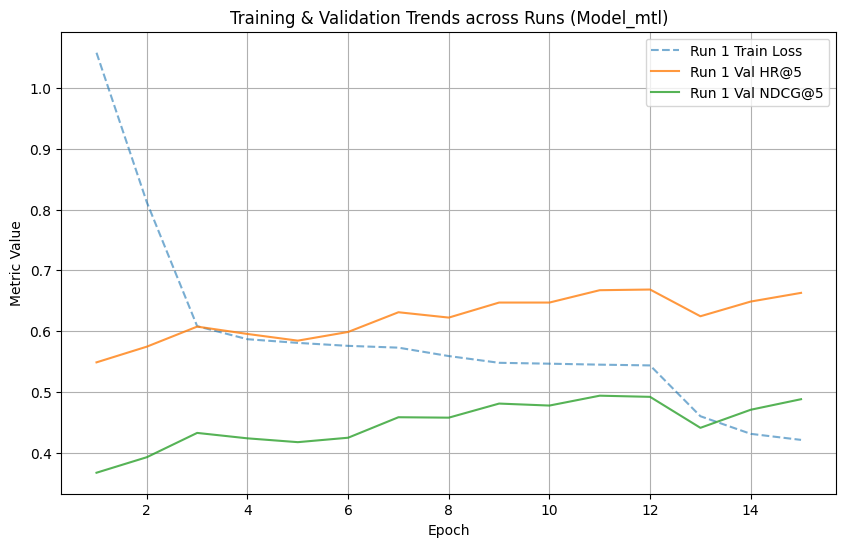

In [21]:
avg_metrics, all_metrics, all_histories = run_multiple(Model_mtl, num_runs=1,
                                                       hidden_channels=5,
                                                       num_epochs=15,
                                                       lr=1e-3,
                                                       patience=5)